<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Twitter_Toxic_Tweets_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Twitter Toxic Tweets

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ajinkyachintawar/sales-and-customer-behaviour-insights

# Unziping the downloaded file
!unzip sales-and-customer-behaviour-insights.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/ajinkyachintawar/sales-and-customer-behaviour-insights
License(s): CC0-1.0
sales-and-customer-behaviour-insights.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  sales-and-customer-behaviour-insights.zip
replace customer_info.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: customer_info.csv       
replace product_info.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: product_info.csv        
replace sales_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sales_data.csv          


In [4]:
df = pd.read_csv('sales_data.csv')
df.head(11)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-25,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-25,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,06-07-25,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,06-07-25,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,06-07-25,DELAYED,Credit Card,West,0.20
5,O190175,C00388,P0005,3,37.89,06-07-25,Delayed,Bank Transfer,North,0.10
6,O272646,C00328,P0027,5,30.83,06-07-25,delivered,PayPal,Central,0.05
7,O411881,C00201,P0019,3,12.56,06-07-25,Delivered,Credit Card,East,0.00
8,O170570,C00076,P0030,3,28.32,06-07-25,delivered,PayPal,Central,0.15
9,O619944,C00330,P0002,1,30.96,06-07-25,DELAYED,Credit Card,South,0.15


In [5]:
df.tail(11)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
2989,O310112,C00392,P0008,1,45.88,06-07-25,delivered,PayPal,East,0.00
2990,O584546,C00250,P0030,3,34.37,06-07-25,Delayed,Credit Card,Central,0.00
2991,O979543,C00174,P0028,5,35.49,06-07-25,delivered,Bank Transfer,North,0.05
2992,O834685,C00262,P0012,1,37.27,06-07-25,Delivered,Bank Transfer,North,0.20
2993,O517776,C00138,P0024,3,17.92,06-07-25,Cancelled,credit card,North,0.15
2994,O650396,C00298,P0005,2,21.88,06-07-25,Delayed,Bank Transfer,Central,0.20
2995,O868860,C00233,P0001,5,43.40,06-07-25,Delivered,Bank Transfer,West,0.20
2996,O949709,C00246,P0029,4,34.04,06-07-25,DELAYED,Bank Transfer,West,0.20
2997,O763639,C00182,P0026,1,42.34,06-07-25,Delivered,credit card,South,0.00
2998,O753958,C00074,P0003,5,35.96,06-07-25,Delivered,Credit Card,Central,0.00


In [6]:
df.shape

(3000, 10)

In [7]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price',
       'order_date', 'delivery_status', 'payment_method', 'region',
       'discount_applied'],
      dtype='object')

In [8]:
df.dtypes

,0
order_id,object
customer_id,object
product_id,object
quantity,object
unit_price,float64
order_date,object
delivery_status,object
payment_method,object
region,object
discount_applied,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2999 non-null   object 
 1   customer_id       2998 non-null   object 
 2   product_id        2995 non-null   object 
 3   quantity          2997 non-null   object 
 4   unit_price        2999 non-null   float64
 5   order_date        2997 non-null   object 
 6   delivery_status   2997 non-null   object 
 7   payment_method    2997 non-null   object 
 8   region            3000 non-null   object 
 9   discount_applied  2483 non-null   float64
dtypes: float64(2), object(8)
memory usage: 234.5+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,2999,2997,O916245,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,2998,499,C00385,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,2995,30,P0010,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,2997,7,2,635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_price,2999.0,NaN,NaN,NaN,28.945388,12.085893,8.0,18.83,28.63,39.64,49.99
order_date,2997,1,06-07-25,2997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_status,2997,7,Delivered,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,2997,5,Bank Transfer,780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,3000,6,North,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_applied,2483.0,NaN,NaN,NaN,0.100262,0.069987,0.0,0.05,0.1,0.15,0.2


In [11]:
df.isnull().sum()

,0
order_id,1
customer_id,2
product_id,5
quantity,3
unit_price,1
order_date,3
delivery_status,3
payment_method,3
region,0
discount_applied,517


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

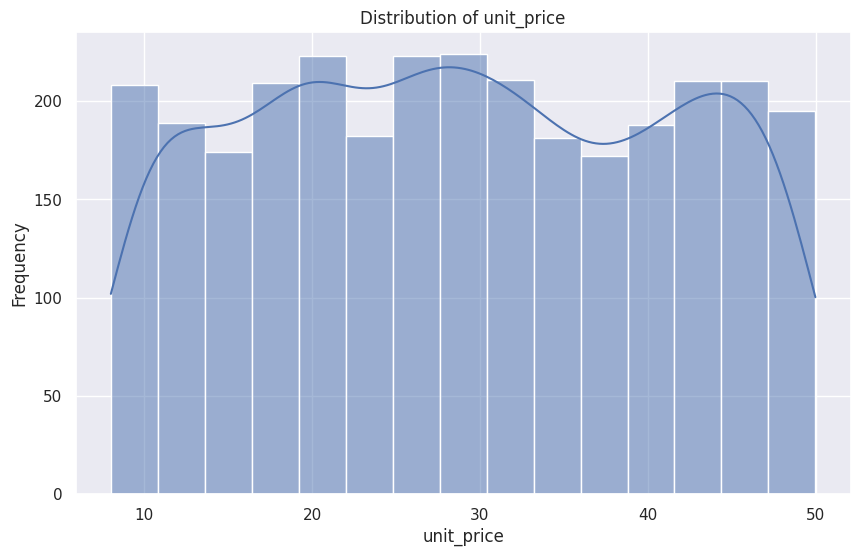

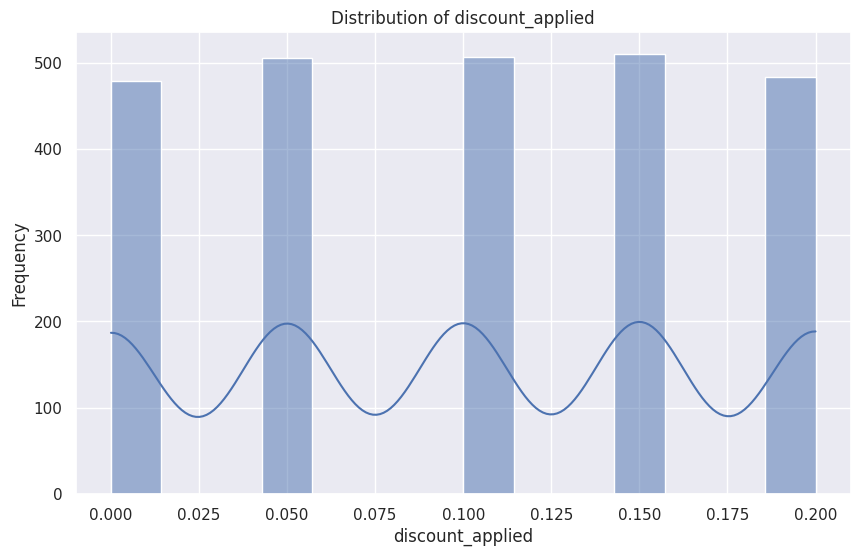

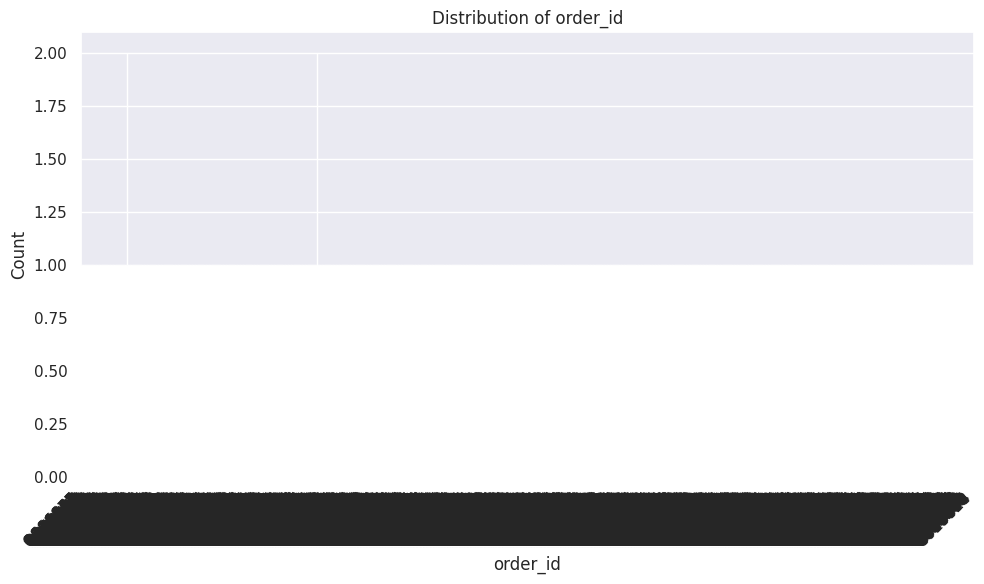

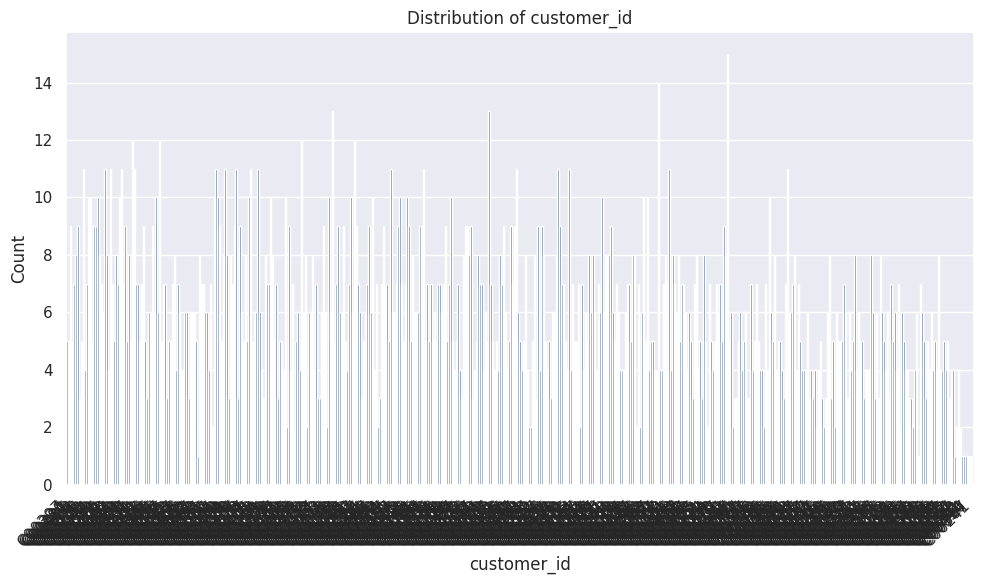

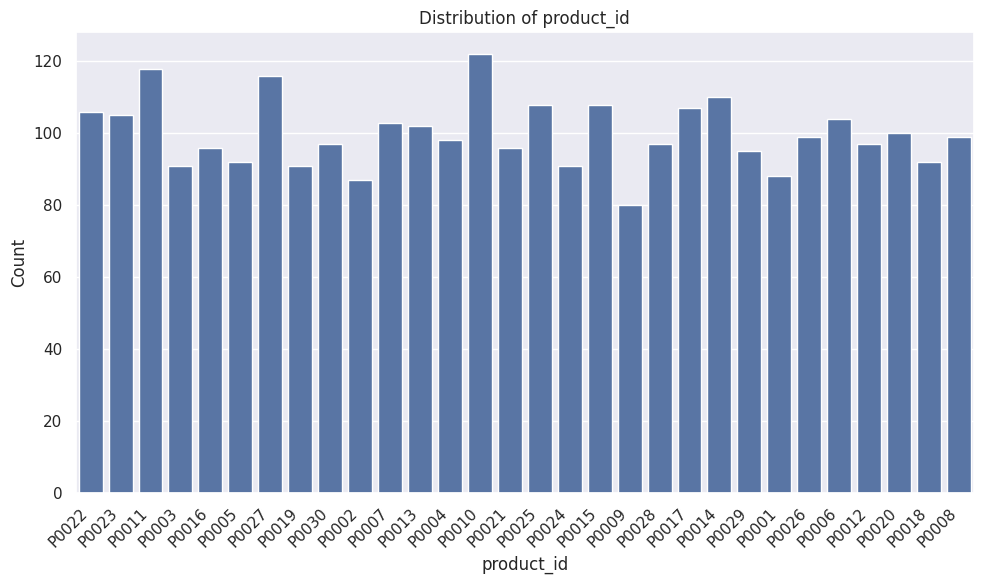

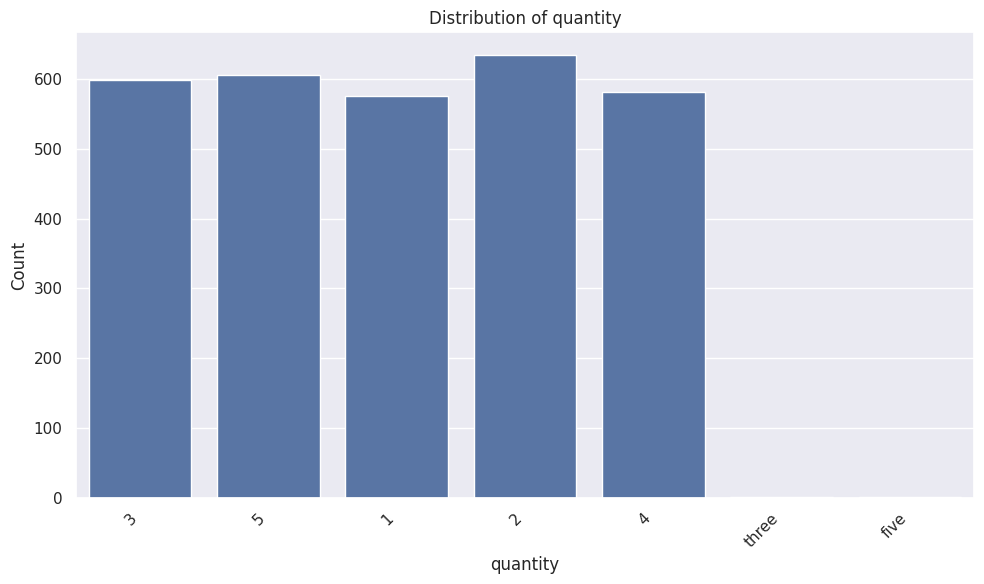

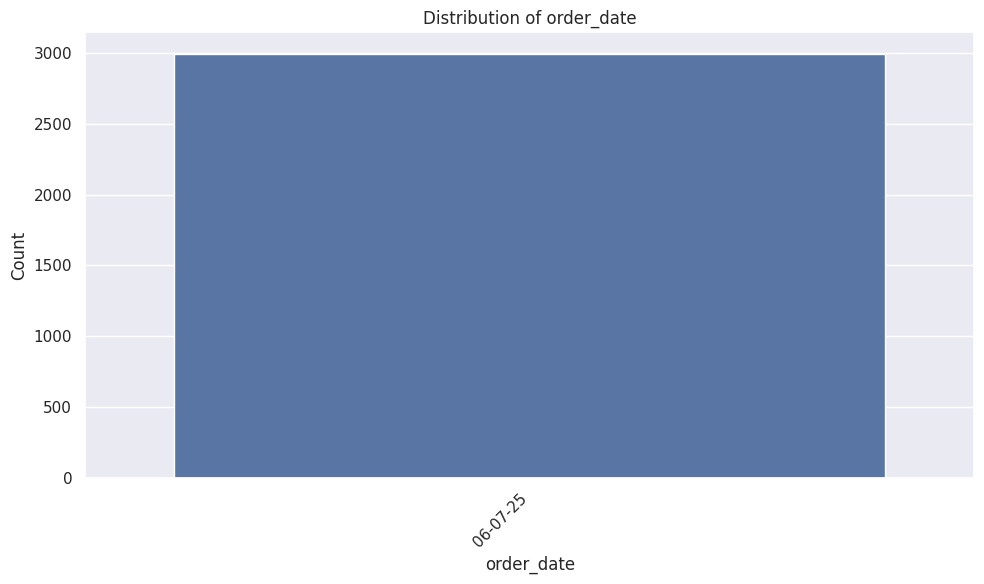

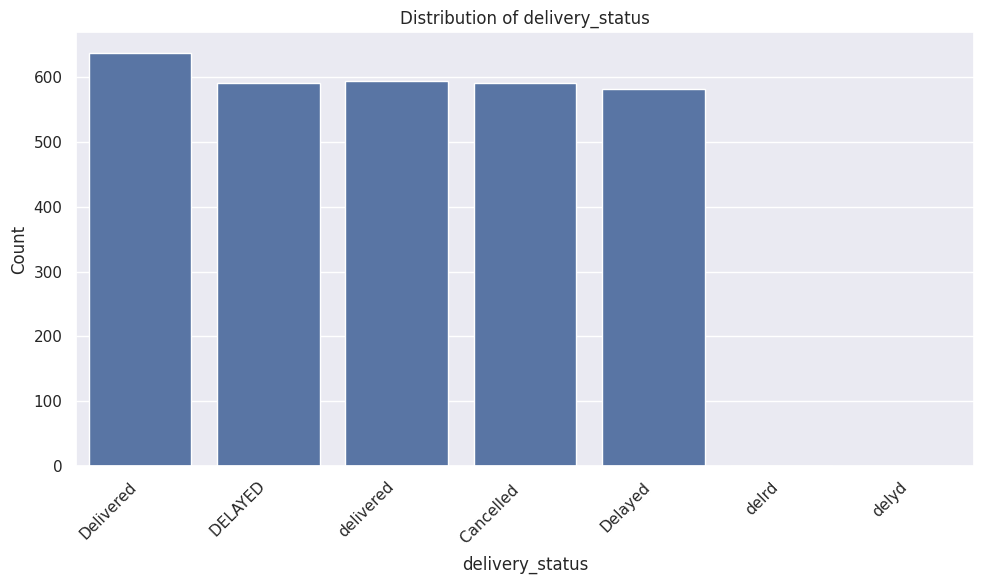

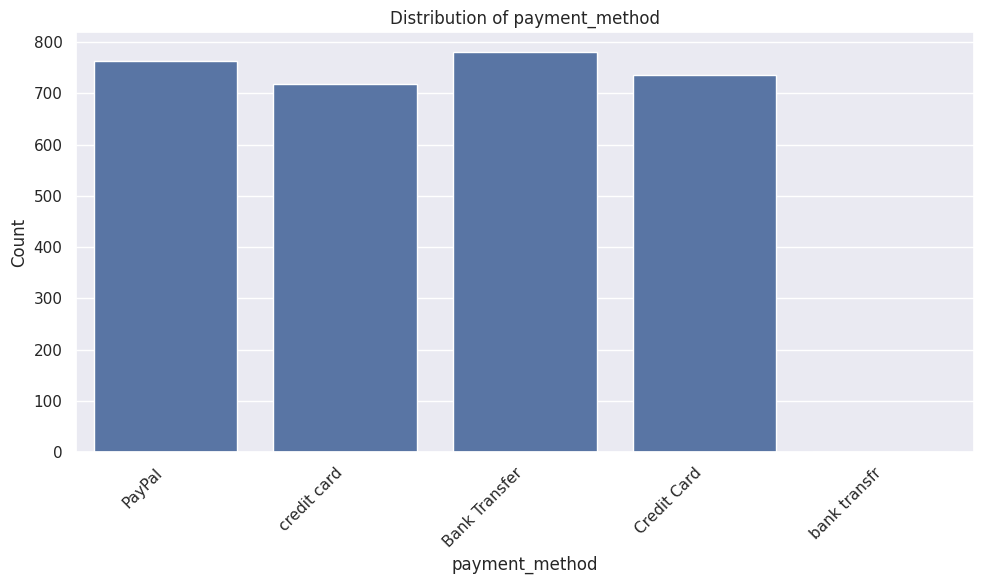

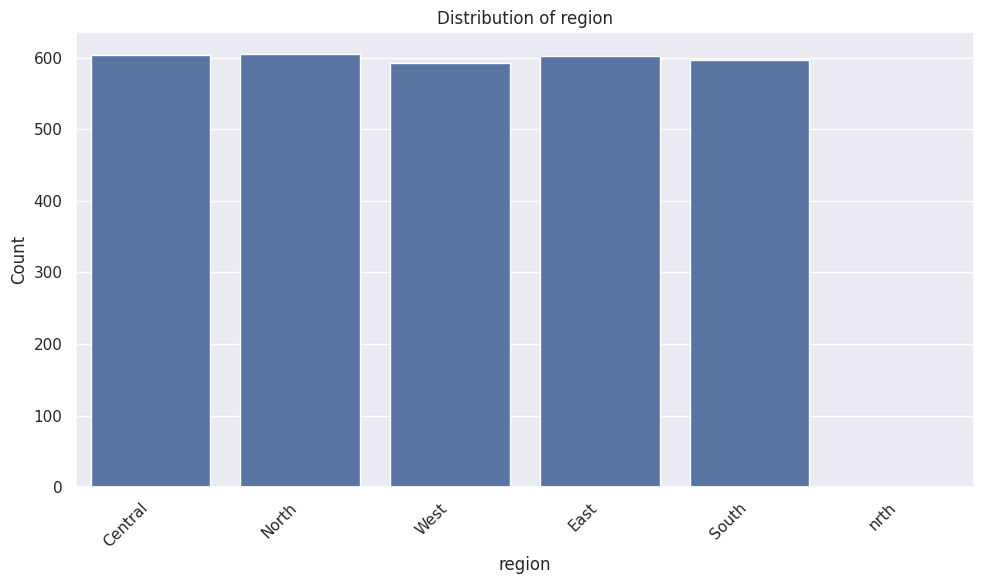

Value counts for order_id:
order_id
O916245    2
O515400    2
O531707    1
O426596    1
O477107    1
          ..
O842017    1
O605680    1
O606964    1
O401865    1
O796311    1
Name: count, Length: 2997, dtype: int64

Value counts for customer_id:
customer_id
C00385    15
C00062    14
C00108    13
C00294    13
C00440    12
          ..
C00452     1
C00135     1
C00036     1
C00367     1
C00241     1
Name: count, Length: 499, dtype: int64

Value counts for product_id:
product_id
P0010    122
P0011    118
P0027    116
P0014    110
P0025    108
P0015    108
P0017    107
P0022    106
P0023    105
P0006    104
P0007    103
P0013    102
P0020    100
P0026     99
P0008     99
P0004     98
P0012     97
P0028     97
P0030     97
P0016     96
P0021     96
P0029     95
P0018     92
P0005     92
P0003     91
P0019     91
P0024     91
P0001     88
P0002     87
P0009     80
Name: count, dtype: int64

Value counts for quantity:
quantity
2        635
5        605
3        598
4        582
1        5

In [13]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

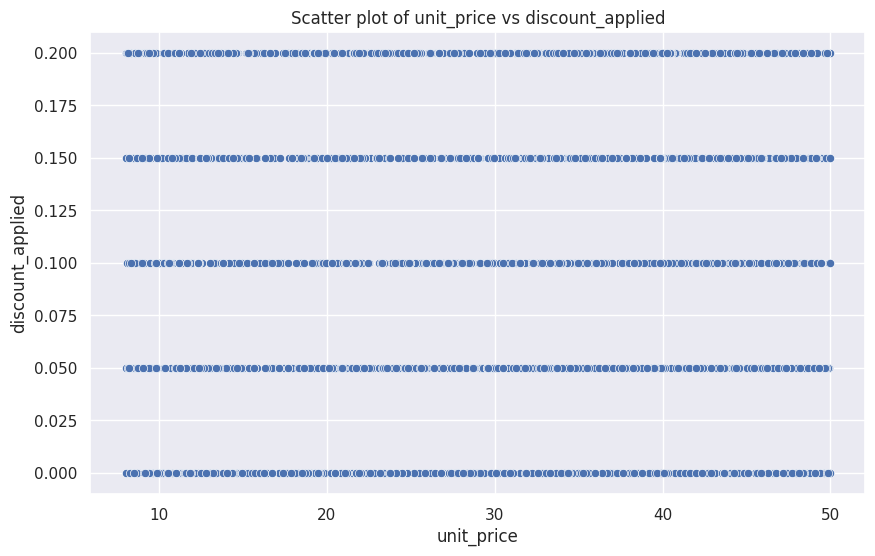

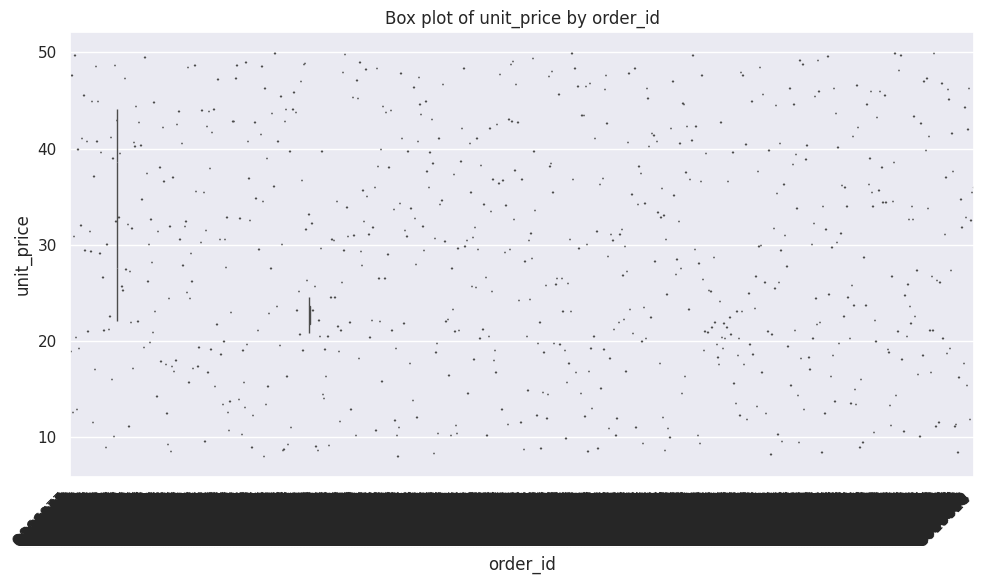

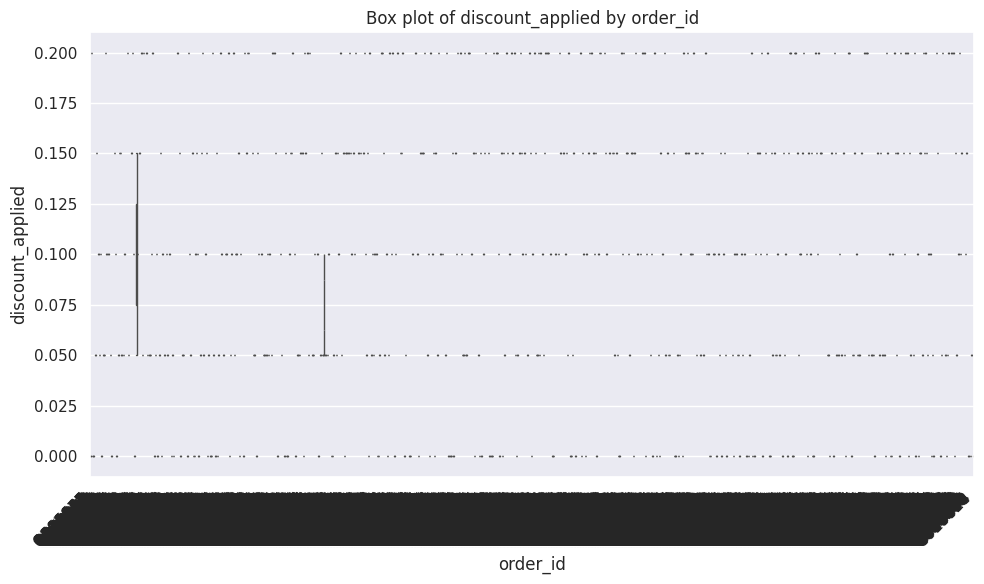

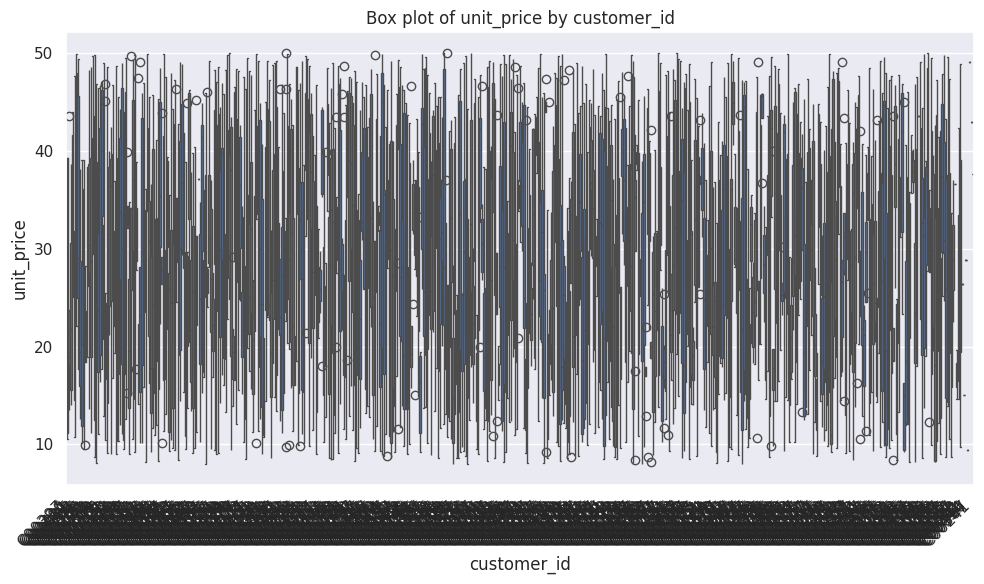

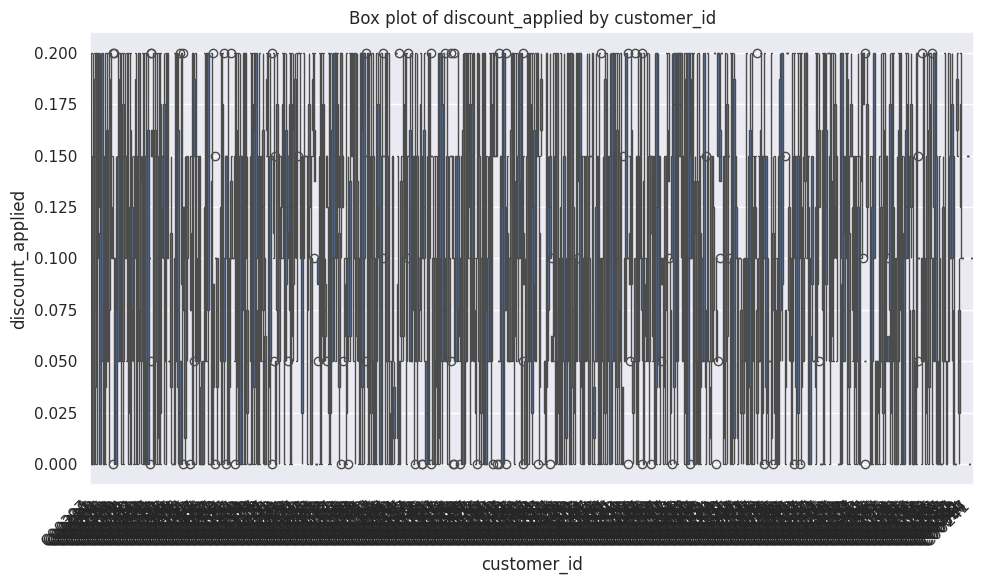

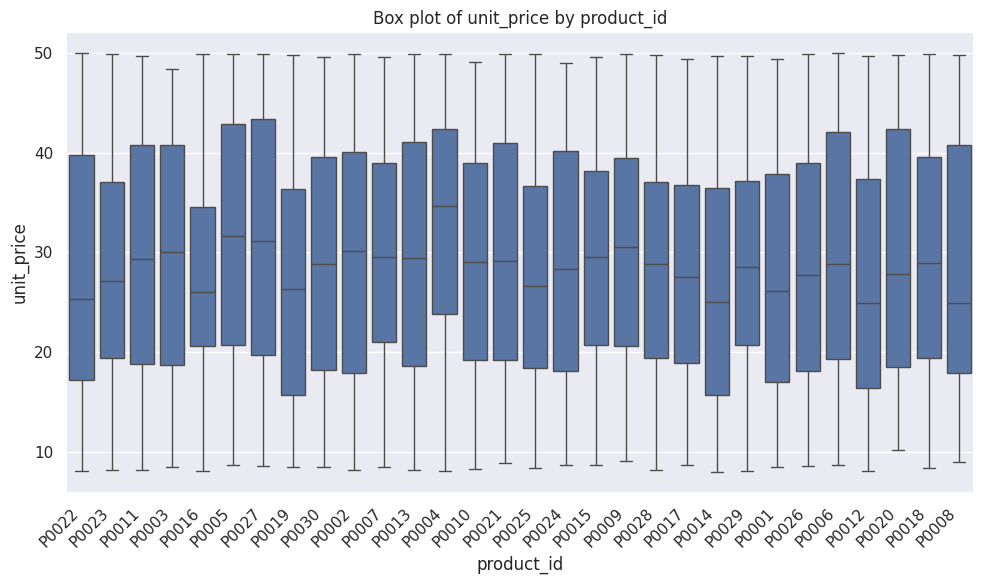

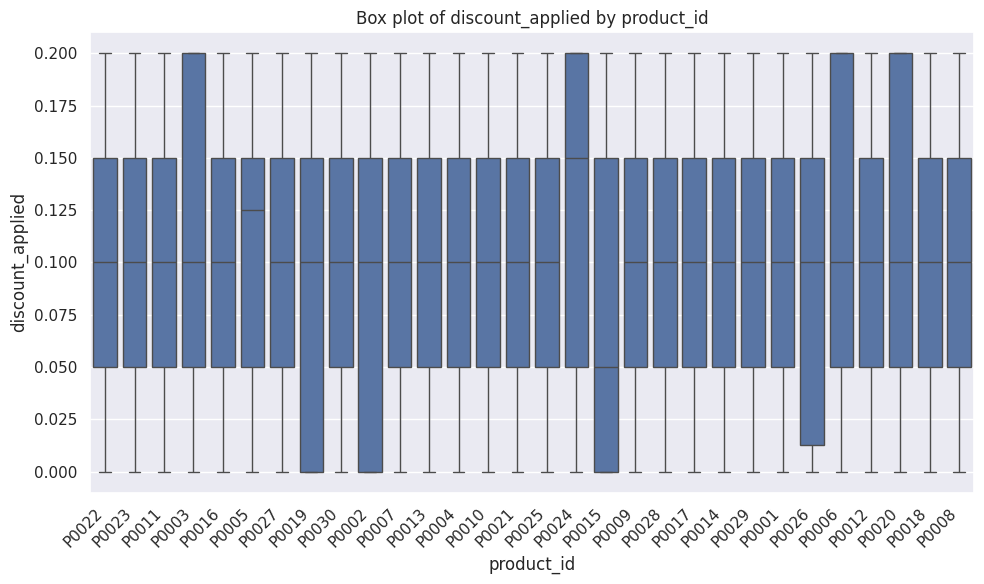

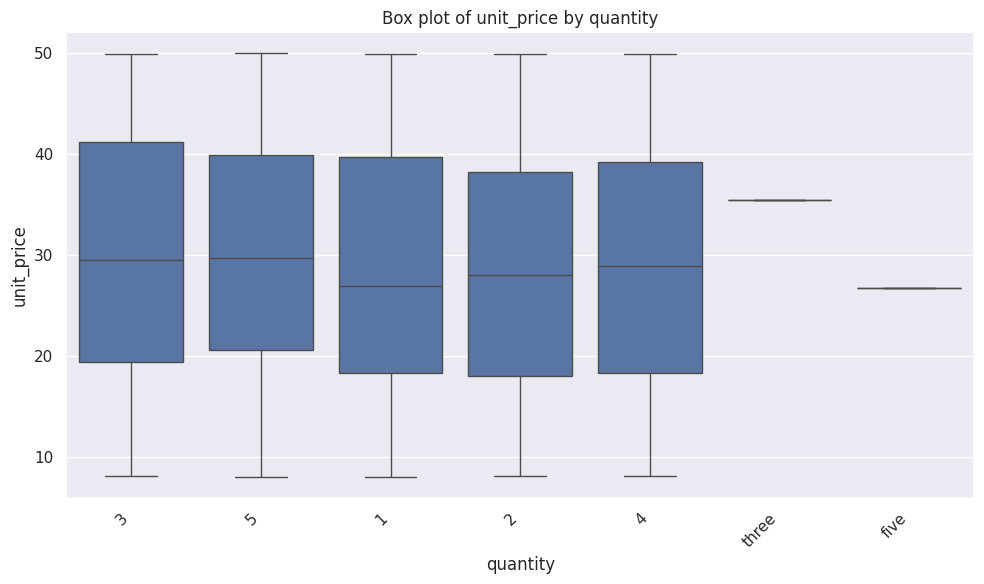

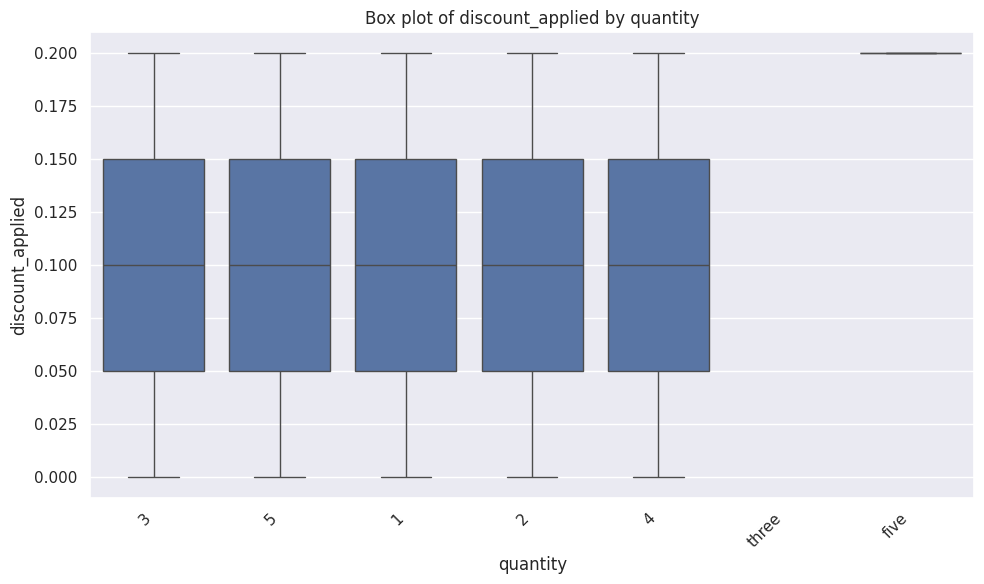

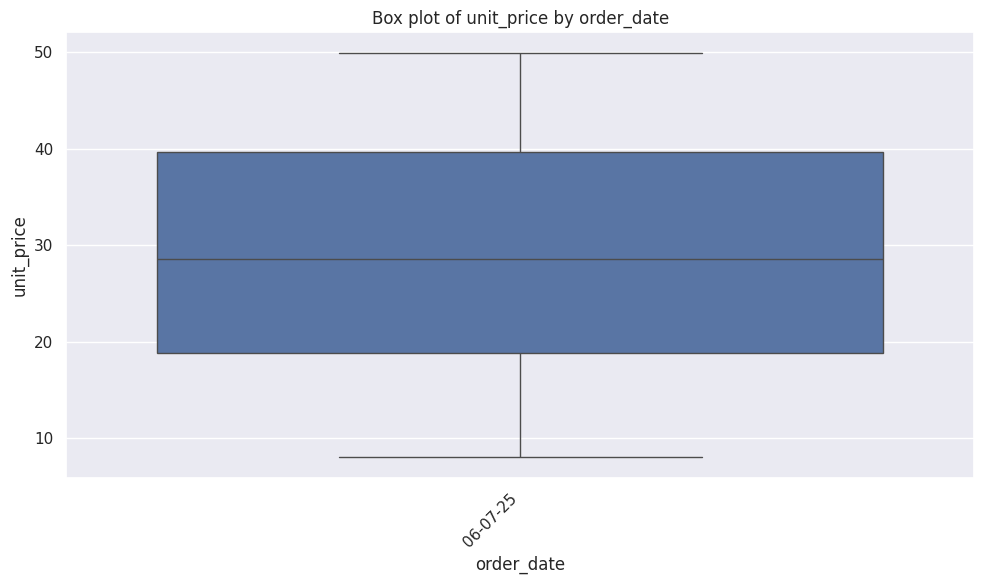

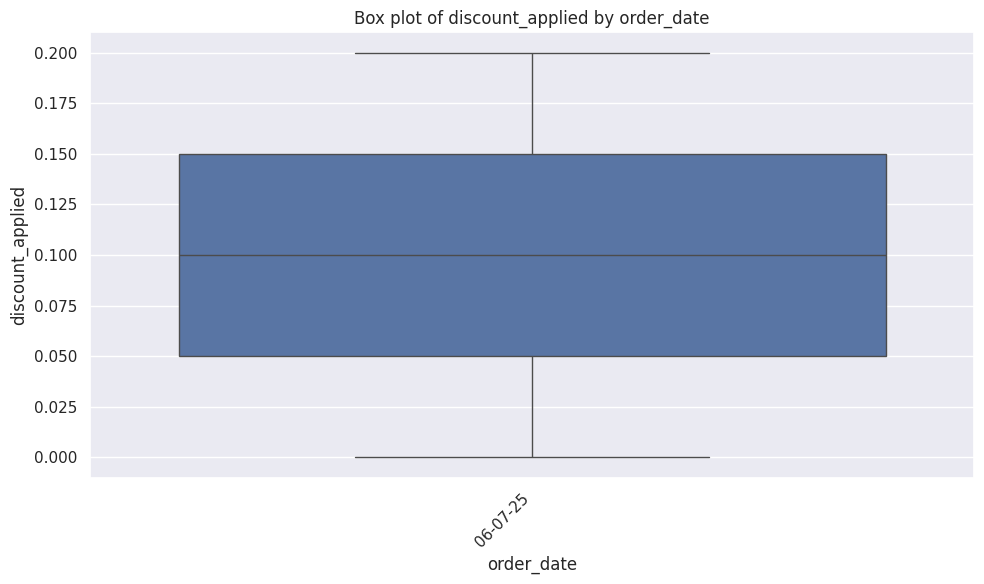

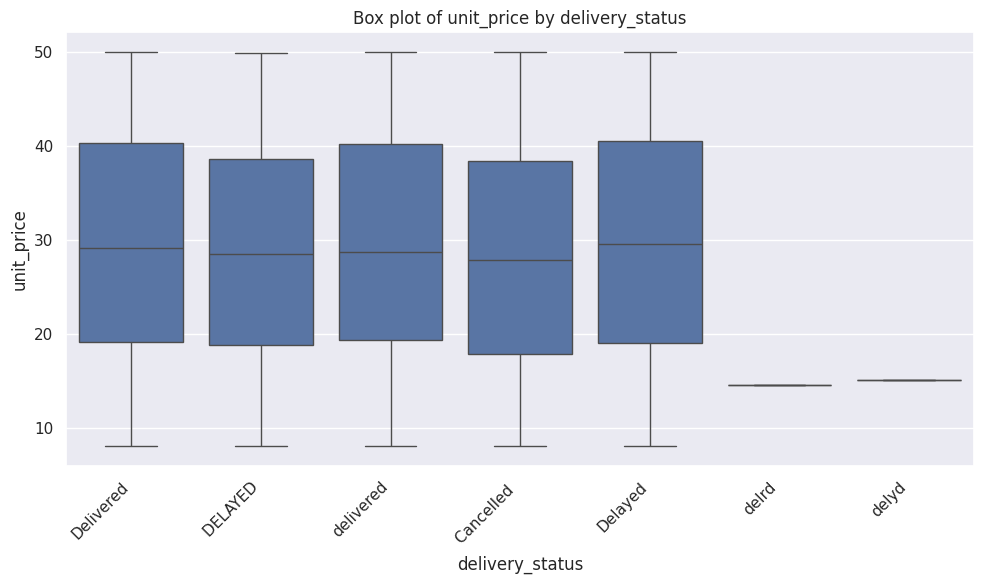

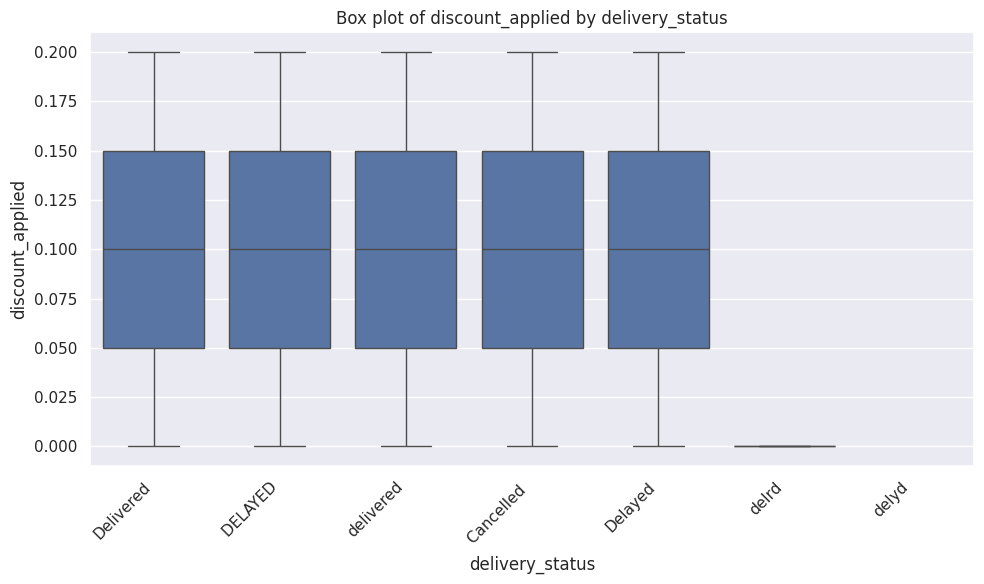

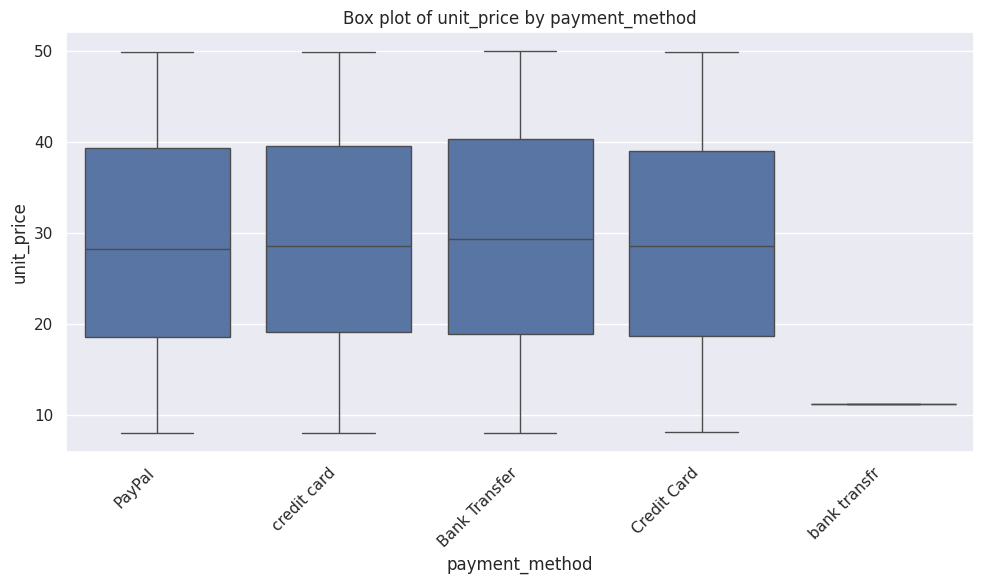

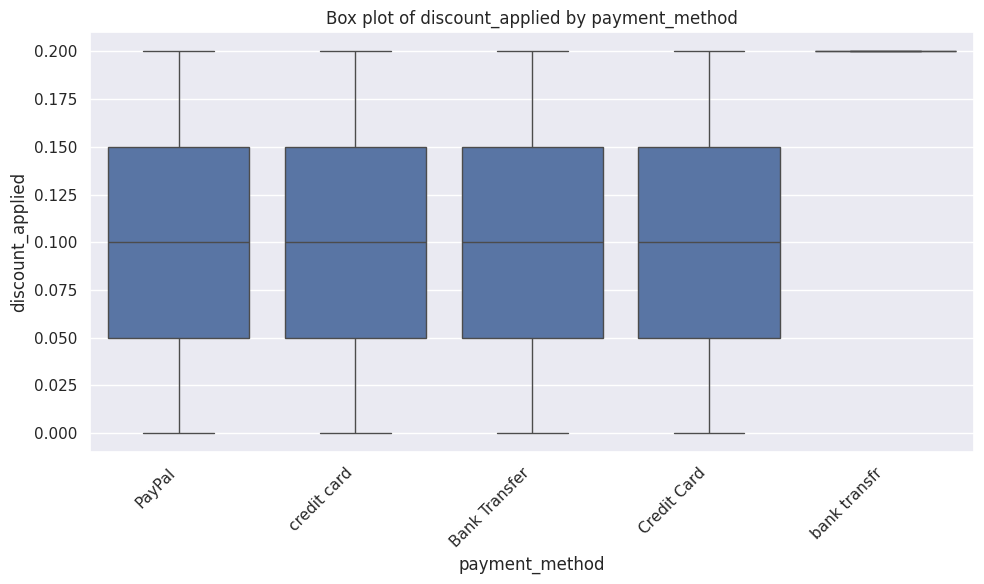

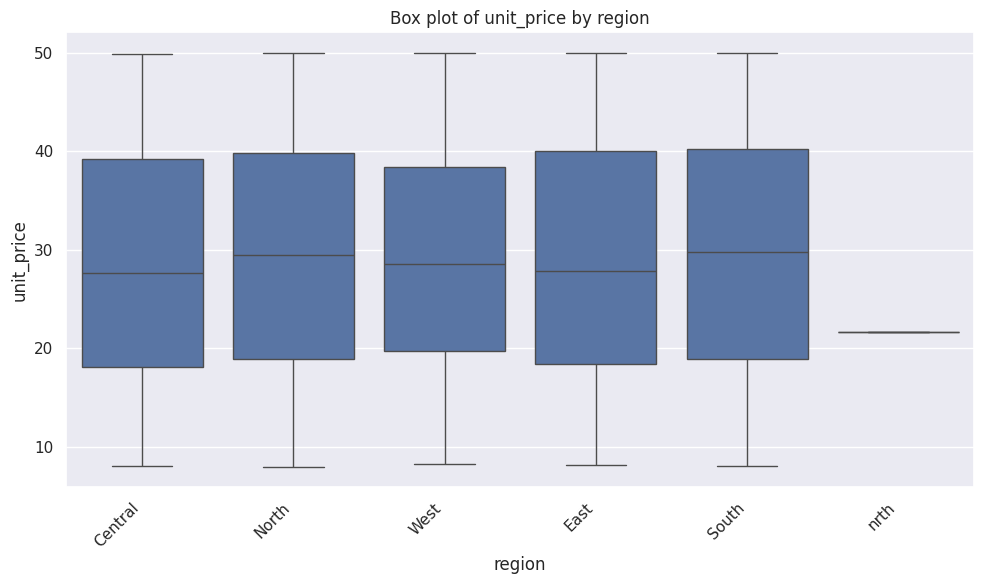

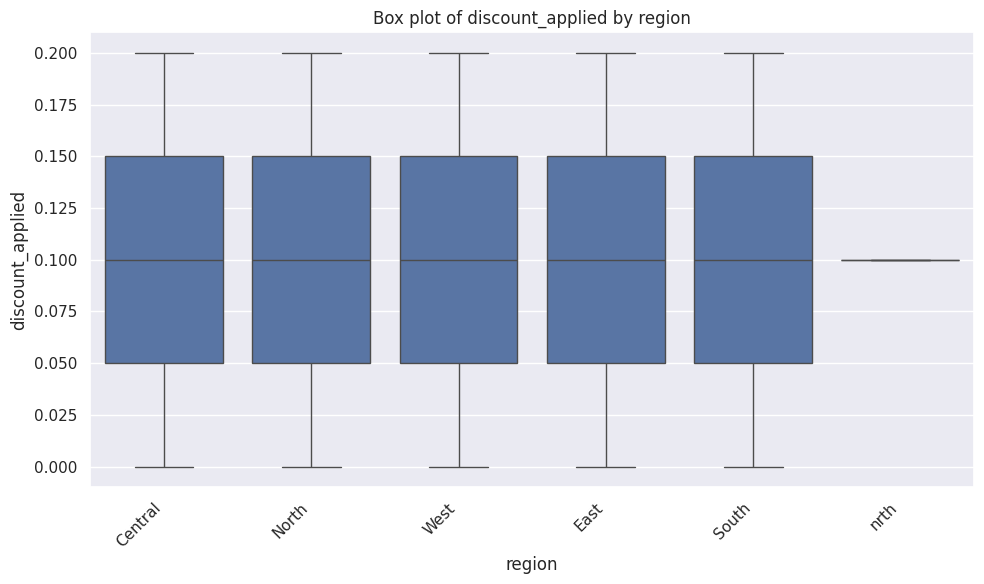

In [14]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

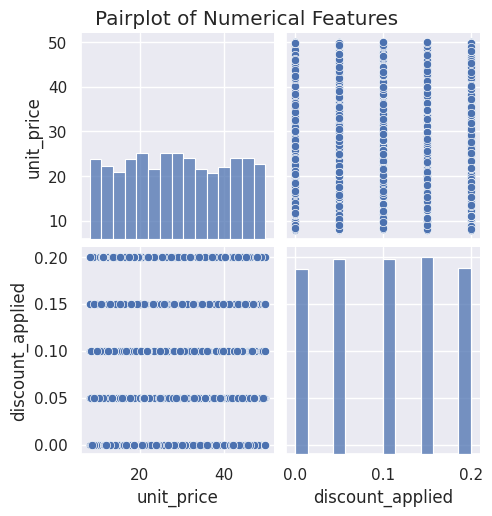

In [15]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

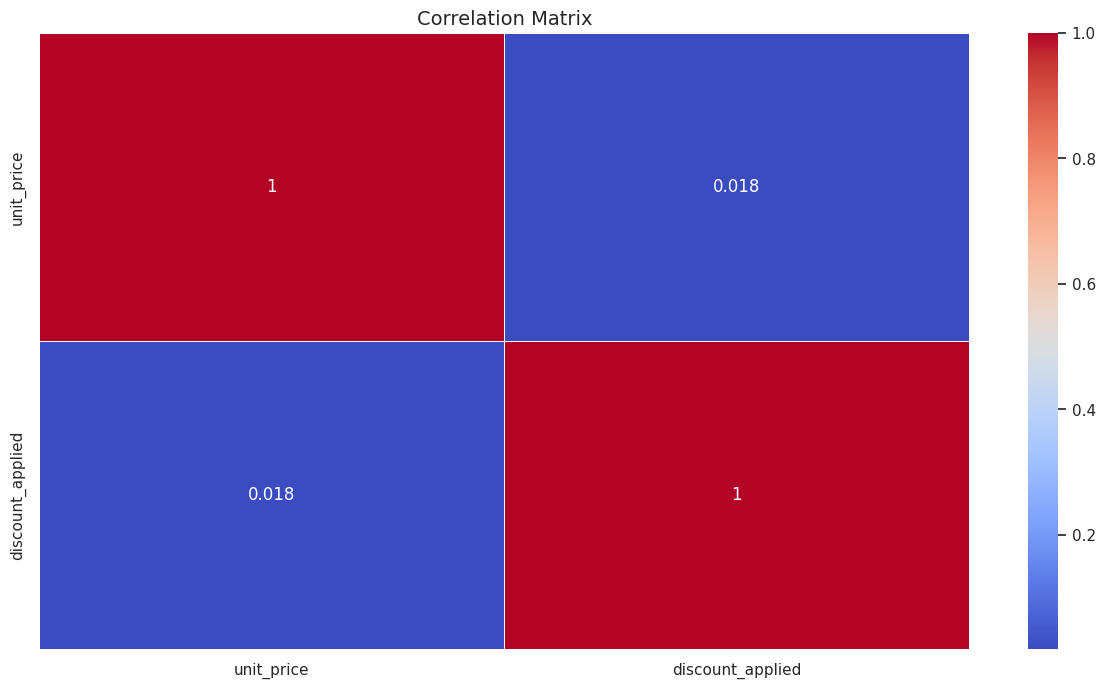

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You